In [47]:
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
from ultralytics import YOLO

In [48]:
cap = cv.VideoCapture(2)
if not cap.isOpened():
    print("Camera kan niet openen")
    exit()
else:
    print("Camera aan")

Camera aan


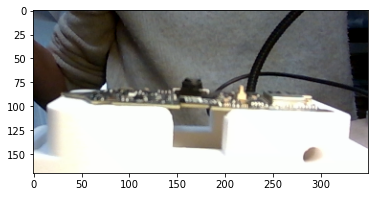

In [122]:
ret, frame = cap.read()
color_correct = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
wb = cv.xphoto.createSimpleWB()
img = wb.balanceWhite(color_correct)

cropped_img = img[180:350, 200:550]

plt.imshow(cropped_img)
plt.show()

In [123]:
#cv.imwrite('Foto15.png', im)

In [124]:
def apply_yolov8(image, confidence_threshold):
    model = YOLO(r'C:\Users\31637\Downloads\best.pt')  
    results = model(image, conf=confidence_threshold)  
    return results

In [125]:
confidence_threshold = 0.80
results = apply_yolov8(cropped_img, confidence_threshold)


0: 320x640 65.0ms
Speed: 3.9ms preprocess, 65.0ms inference, 1.0ms postprocess per image at shape (1, 3, 320, 640)


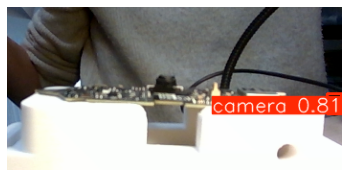

In [126]:
annotated_img = cropped_img.copy()
result_img = results[0].plot()

plt.imshow(result_img)  # RGB afbeelding weergeven
plt.axis('off')
plt.show()